In [2]:
# load lib
library(tidyverse)
library(glmnet)
library(glmmTMB)
library(caret)
library(DHARMa)
library(readr)
library(dplyr)
library(janitor)

Warning message:
"Paket 'ggplot2' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'purrr' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'forcats' wurde unter R Version 4.4.1 erstellt"
-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.1     v stringr   1.5.1
v ggplot2   4.0.2     v tibble    3.2.1
v lubridate 1.9.3     v tidyr     1.3.1
v purrr     1.2.1     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"Paket 'glmnet' wurde unter R Version 4.4.1 erstellt"
Lade n"otiges Paket: Matrix


Attache Paket: 'Matrix'


Die folgenden Objekte sind maskiert von 'package:tidyr':

    expand, pack, unpack


Loaded glmnet 4.1-10

Warning message:
"Paket 'glm

In [8]:
drop_redundant_yn_features <- function(df) {
  # Get all column names
  cols <- names(df)
  
  # Find Yes/No pairs by stripping the suffix
  # Pattern: variable name ends in " - Yes" or " - No"
  yes_cols <- cols[grepl("_yes$", cols)]
  no_cols  <- cols[grepl("_no$",  cols)]
  
  # Get base names for each
  yes_bases <- sub("_yes$", "", yes_cols)
  no_bases  <- sub("_no$",  "", no_cols)
  
  # Find bases that have BOTH a Yes and No column
  paired_bases <- intersect(yes_bases, no_bases)
  
  cols_to_drop <- c()
  
  for (base in paired_bases) {
    yes_col <- yes_cols[yes_bases == base]
    no_col  <- no_cols[no_bases == base]
    
    # Count NAs in each
    yes_nas <- sum(is.na(df[[yes_col]]))
    no_nas  <- sum(is.na(df[[no_col]]))
    
    # Drop whichever has more NAs; if tied, drop "No" (keep "Yes")
    if (no_nas >= yes_nas) {
      cols_to_drop <- c(cols_to_drop, no_col)
    } else {
      cols_to_drop <- c(cols_to_drop, yes_col)
    }
  }
  
  cat("Dropping", length(cols_to_drop), "redundant columns:\n")
  #cat(paste(" ", cols_to_drop), sep = "\n")
  
  df[, !names(df) %in% cols_to_drop]
}

set.seed(100)

df <- read_csv("data/merged_with_svi.csv", show_col_types = FALSE) |> clean_names() 
#df <- read_csv("data/merged_with_svi.csv") |> clean_names()

# outbreak >=2 is with outbreak, vice versa.
# df$outbreak <- as.integer(df$outbreak >= def_outbreak)

# SVI specific, because it does not include the data for Mcculloch, Mclennan, Mcmullen and Dewitt, 
# if we continue the prev way of data processing it will remove all SVI related features, so we remove these 4 counties.
#df <- df[!df$county %in% c("Mcculloch", "Mclennan", "Mcmullen", "Dewitt"), ]

df <- df %>% filter(!county %in% c("Mcculloch", "Mclennan", "Mcmullen", "Dewitt", "Loving"))
df_raw <- df
df$density <- df$population*1.0/df$area_sqmi
df <- df %>% select(-c("county", "area_sqmi"), -starts_with("m_"), -starts_with("mp_"), -starts_with("e_"), -starts_with("epl_"), -starts_with("spl_"), -starts_with("rpl_"), -starts_with("f_"))
df <- df[,colSums(is.na(df)) == 0]
df <- df %>% select(-c("ep_minrty", "ep_hisp", "ep_afam", "ep_pov150", "ep_uninsur"))

df <- drop_redundant_yn_features(df)

# split the data with stratified sampling
# strata <- ifelse(df$outbreak > 0, "nonzero", "zero")
index <- createDataPartition(df$outbreak, p = 0.75, list = FALSE)
train <- df[index,]
test <- df[-index,]
PHR <- train$phr
offset <- log(train$enrollment)
outbreak <- log(train$outbreak + 1)
train <- train %>% select(-c("phr", "enrollment", "population", "outbreak"))

Dropping 55 redundant columns:


In [9]:
X <- as.matrix(train)
y <- outbreak
X <- X[, abs(cor(X, log(y + 1), use = "complete.obs", method = "spearman")) >= 0.1]

# Start with full list of candidates
candidates <- colnames(X)

i <- 1
while (i < length(candidates)) {
  j <- i + 1
  while (j <= length(candidates)) {
    rho <- cor(X[, candidates[i]], X[, candidates[j]], 
               method = "spearman", use = "complete.obs")
    if (abs(rho) >= 0.7) {
      # Drop whichever has weaker correlation with outcome
      rho_i <- abs(cor(X[, candidates[i]], log(y + 1), method = "spearman", use = "complete.obs"))
      rho_j <- abs(cor(X[, candidates[j]], log(y + 1), method = "spearman", use = "complete.obs"))
      if (rho_i >= rho_j) {
        candidates <- candidates[-j]  
      } else {
        candidates <- candidates[-i]  
        j <- i + 1
      }
    } else {
      j <- j + 1
    }
  }
  i <- i + 1
}

X <- X[, candidates]
X

cve,asthma_status_never,bmi_3_categories_recommended_range,clnscpy_sgmscpy_colonoscopy,dr_rx_pain_talk_yes,general_health_good,heavy_drinking_no,hlth_affected_activ_5_days_5_or_more_days,hysterectomy_yes,kidney_disease_no,...,ep_nohsdp,ep_age65,ep_age17,ep_disabl,ep_sngpnt,ep_limeng,ep_munit,ep_mobile,ep_noint,ep_asian
2.54,85.1,25.4,83.3,64.2,30.9,94.9,19.8,28.6,94.6,...,15.2,14.8,19.0,16.8,7.8,2.0,3.5,19.7,17.8,0.7
1.91,85.9,21.7,82.0,70.4,30.4,94.1,16.3,28.1,95.1,...,26.2,9.6,30.6,11.9,5.4,8.2,2.5,19.7,9.2,0.5
2.06,90.4,27.0,77.9,49.3,31.1,97.3,21.6,25.8,93.0,...,11.4,27.6,17.4,16.9,4.0,0.7,5.3,15.7,10.6,1.7
2.70,86.0,30.0,88.6,58.2,34.1,96.7,20.6,31.9,92.7,...,8.8,20.6,22.7,17.6,4.6,1.2,0.3,10.3,16.8,0.2
1.08,82.4,28.7,84.6,59.1,33.9,91.0,22.1,20.0,95.9,...,19.4,14.8,26.9,11.8,7.9,5.9,1.4,33.8,15.3,0.5
3.55,86.0,32.5,87.8,48.8,37.2,92.5,14.8,19.5,97.4,...,12.1,20.0,23.6,13.0,6.8,3.5,1.6,22.1,19.4,0.5
3.78,82.4,28.7,84.6,59.1,33.9,91.0,22.1,20.0,95.9,...,8.0,27.9,16.8,18.8,3.4,2.3,0.2,26.0,12.1,0.5
2.09,84.4,34.1,86.3,62.1,34.7,92.8,19.1,17.0,95.7,...,16.9,15.4,25.5,12.1,4.9,4.8,2.2,24.4,15.6,0.7
0.88,86.0,30.0,88.6,58.2,34.1,96.7,20.6,31.9,92.7,...,13.0,23.9,23.5,23.6,1.4,0.0,0.5,7.9,18.1,0.0
1.48,90.4,27.0,77.9,49.3,31.1,97.3,21.6,25.8,93.0,...,19.8,12.6,20.2,15.2,6.5,3.2,3.0,15.7,24.4,0.6


[1] 0.1229185
 [1] "cve"                                       
 [2] "clnscpy_sgmscpy_colonoscopy"               
 [3] "dr_rx_pain_talk_yes"                       
 [4] "heavy_drinking_no"                         
 [5] "poor_physical_health_5_days_5_or_more_days"
 [6] "routine_checkup_within_the_past_year"      
 [7] "sigm_past_5_yrs_50_75_ia_no"               
 [8] "skin_cancer_no"                            
 [9] "suicidal_ideation_no"                      
[10] "ep_nohsdp"                                 
[11] "ep_age65"                                  
[12] "ep_disabl"                                 
[13] "ep_mobile"                                 
[14] "ep_noint"                                  


32 x 1 sparse Matrix of class "dgCMatrix"
                                                      s0
(Intercept)                                -19.342792272
cve                                          0.012437010
asthma_status_never                         -0.017290954
bmi_3_categories_recommended_range          -0.017885370
clnscpy_sgmscpy_colonoscopy                  0.029352296
dr_rx_pain_talk_yes                          0.018394687
general_health_good                         -0.032388311
heavy_drinking_no                            0.058828591
hlth_affected_activ_5_days_5_or_more_days   -0.016645906
hysterectomy_yes                            -0.009645396
kidney_disease_no                           -0.053837555
last_dentist_visit_within_the_past_2_years  -0.007906619
mammogram_past_2_yrs_40_ia_yes              -0.042420604
pain_med_not_rx_no                          -0.036968085
poor_mental_health_5_days_5_or_more_days    -0.055346472
poor_physical_health_5_days_5_or_more_days   0

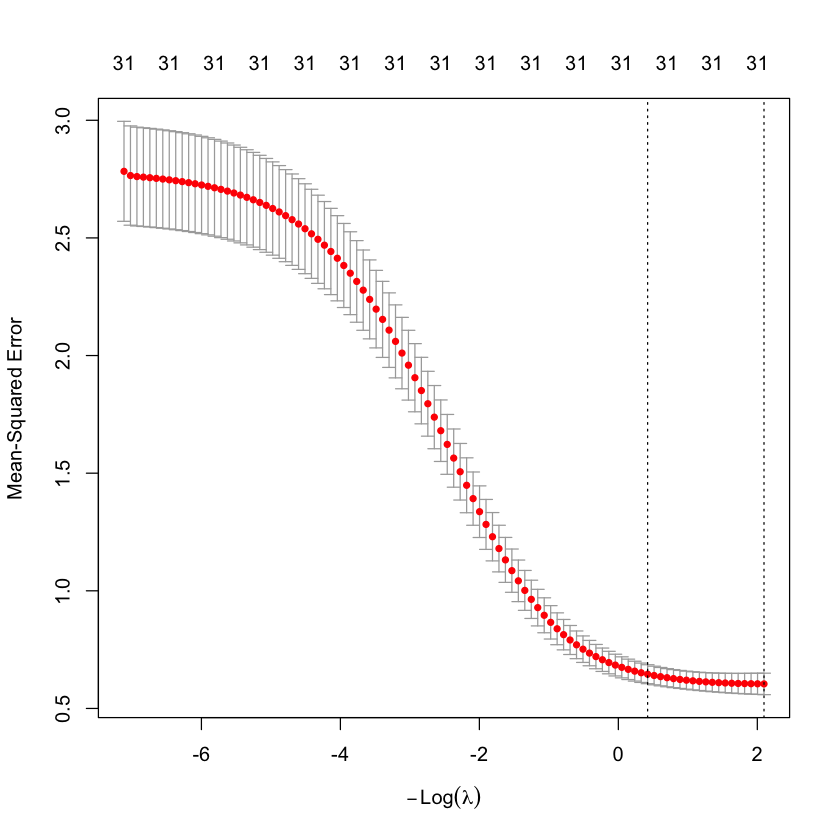

In [15]:
set.seed(100)
cv.lasso <- cv.glmnet(X, log(y + 1), offset = offset, alpha = 0)  # alpha=1 for Lasso
plot(cv.lasso)
best.lambda <- cv.lasso$lambda.min
print(best.lambda)
lasso.model <- glmnet(X, log(y + 1), offset = offset, alpha = 0, lambda = best.lambda)
lasso_coef <- coef(lasso.model)
lasso_vars <- rownames(lasso_coef)[
  lasso_coef[, 1] >= 1e-5 & !grepl("Intercept", rownames(lasso_coef))
]
print(lasso_vars)
X_f <- X[, lasso_vars, drop = FALSE]
model_df <- cbind(
  data.frame(outbreak = log(y + 1), enrollment = exp(offset), PHR = PHR),X_f
)
coef(lasso.model)

Warning message in glmmTMB(outbreak ~ cve + dr_rx_pain_talk_yes + heavy_drinking_no + :
"non-integer counts in a nbinom2 model"
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
"Model convergence problem; false convergence (8). See vignette('troubleshooting'), help('diagnose')"


 Family: nbinom2  ( log )
Formula:          
outbreak ~ cve + dr_rx_pain_talk_yes + heavy_drinking_no + +skin_cancer_no +  
    suicidal_ideation_no + ep_age65 + ep_disabl + ep_noint +  
    offset(log(enrollment)) + (1 | PHR)
Data: model_df

      AIC       BIC    logLik -2*log(L)  df.resid 
    126.6     162.1     -52.3     104.6       176 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 PHR    (Intercept) 0.1003   0.3167  
Number of obs: 187, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 3.91e+44 

Conditional model:
                      Estimate Std. Error z value Pr(>|z|)
(Intercept)          -45.85780        NaN     NaN      NaN
cve                    0.22082        NaN     NaN      NaN
dr_rx_pain_talk_yes    0.29910        NaN     NaN      NaN
heavy_drinking_no      0.22706        NaN     NaN      NaN
skin_cancer_no         1.28876        NaN     NaN      NaN
suicidal_ideation_no  -1.38436        NaN     NaN      NaN
ep_age65         

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0001569 0.0054848 0.0276168 0.1642699 0.1333334 2.1381572 


 0  1  2 
57  3  2 

      predicted
actual  0  1  2
    0  48  3  1
    1   3  0  0
    2   2  0  0
    5   1  0  0
    7   1  0  0
    12  0  0  1
    28  1  0  0
    60  1  0  0

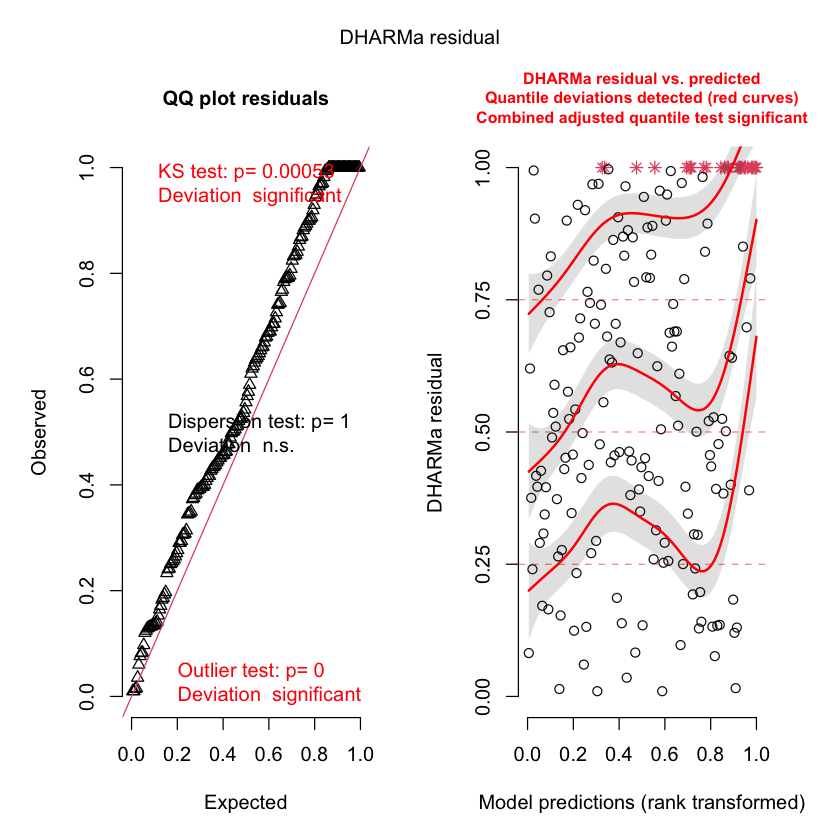

In [16]:
library(car)

# # Fit a standard glm (not glmmTMB) just for VIF calculation
# vif_formula <- as.formula(
#   paste("outbreak ~", paste(c(lasso_vars, "offset(log(enrollment))"), collapse = " + "))
# )

# vif_fit <- glm(vif_formula, data = model_df, family = MASS::negative.binomial(theta = 1))
# vif(vif_fit)
# summary(fit)
fit <- glmmTMB(
  # outbreak ~ mammogram_past_2_yrs_40_ia_no+ep_age65+mp_age17+  
  #   offset(log(enrollment)) + (1 | PHR),
  outbreak ~ cve+ dr_rx_pain_talk_yes+heavy_drinking_no+
  + skin_cancer_no + suicidal_ideation_no+ep_age65+ep_disabl+ep_noint+     
    offset(log(enrollment)) + (1 | PHR),
  data   = model_df,
  family = nbinom2()
)
summary(fit)

sim <- simulateResiduals(fit)
plot(sim)

test_df <- cbind(
  data.frame(outbreak = test$outbreak, enrollment = test$enrollment, PHR = test$phr),
  test[, lasso_vars, drop = FALSE]
)

pred <- predict(fit, newdata = test_df, type = "response")

summary(pred)
table(round(pred))
table(actual = test_df$outbreak, predicted = round(pred))

Warning message in glmmTMB(outbreak ~ pct_uninsured + heavy_drinking_no + mammogram_past_2_yrs_40_ia_no + :
"non-integer counts in a nbinom2 model"


 Family: nbinom2  ( log )
Formula:          
outbreak ~ pct_uninsured + heavy_drinking_no + mammogram_past_2_yrs_40_ia_no +  
    skin_cancer_no + poly(ep_age65, 2) + poly(mp_age17, 2) +  
    ep_disabl + mp_groupq + f_theme1 + mp_aian + offset(log(enrollment)) +  
    (1 | PHR)
Zero inflation:            ~1
Data: model_df_scaled

      AIC       BIC    logLik -2*log(L)  df.resid 
    197.9     249.6     -83.0     165.9       171 

Random effects:

Conditional model:
 Groups Name        Variance  Std.Dev. 
 PHR    (Intercept) 1.139e-10 1.067e-05
Number of obs: 187, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 1.12 

Conditional model:
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                   -11.2626     0.3740 -30.118  < 2e-16 ***
pct_uninsured                   0.5298     0.2424   2.186   0.0288 *  
heavy_drinking_no               0.6129     0.3785   1.619   0.1054    
mammogram_past_2_yrs_40_ia_no   1.7913     0.3696   4.84

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.000e+00 4.062e+06 4.193e+17 5.402e+40 2.351e+28 3.348e+42 


                   0                    7                   14 
                   9                    1                    1 
                 128                  334                 1947 
                   1                    1                    1 
                9241              1802833             10841039 
                   1                    1                    1 
            20018037            178209952           1908478090 
                   1                    1                    1 
          3518025953          31073882843        3492575598907 
                   1                    1                    1 
       3729119653449        8604031704377        9763612090735 
                   1                    1                    1 
     247176014150121      766972496874653     4581823040074227 
                   1                    1                    1 
   42176060739385008   351531899747790720   487069721430026304 
                   1                   

      predicted
actual 0 7 14 128 334 1947 9241 1802833 10841039 20018037 178209952 1908478090
    0  9 1  1   1   1    1    1       1        1        1         1          1
    1  0 0  0   0   0    0    0       0        0        0         0          0
    2  0 0  0   0   0    0    0       0        0        0         0          0
    3  0 0  0   0   0    0    0       0        0        0         0          0
    4  0 0  0   0   0    0    0       0        0        0         0          0
    5  0 0  0   0   0    0    0       0        0        0         0          0
    14 0 0  0   0   0    0    0       0        0        0         0          0
      predicted
actual 3518025953 31073882843 3492575598907 3729119653449 8604031704377
    0           1           1             1             0             0
    1           0           0             0             0             0
    2           0           0             0             1             0
    3           0           0             0     

...

[1] 91.0 97.3

[1] -1.869120  1.546438

 Family: nbinom2  ( log )
Formula:          
outbreak ~ pct_uninsured + heavy_drinking_no + mammogram_past_2_yrs_40_ia_no +  
    skin_cancer_no + ep_disabl + mp_groupq + f_theme1 + mp_aian +  
    offset(log(enrollment)) + (1 | PHR)
Data: model_df

      AIC       BIC    logLik -2*log(L)  df.resid 
    189.0     224.6     -83.5     167.0       176 

Random effects:

Conditional model:
 Groups Name        Variance  Std.Dev.
 PHR    (Intercept) 3.269e-05 0.005718
Number of obs: 187, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 1.15 

Conditional model:
                               Estimate Std. Error z value Pr(>|z|)    
(Intercept)                   -36.50947   23.32095  -1.566   0.1175    
pct_uninsured                   0.09471    0.04376   2.164   0.0305 *  
heavy_drinking_no               0.34173    0.19382   1.763   0.0779 .  
mammogram_past_2_yrs_40_ia_no   0.29546    0.05842   5.057 4.25e-07 ***
skin_cancer_no                 -0.20106    0.19239  -1.045   0.29

pct_uninsured             heavy_drinking_no 
                     1.533204                      1.656383 
mammogram_past_2_yrs_40_ia_no                skin_cancer_no 
                     2.253840                      2.238328 
                     ep_age65                      mp_age17 
                     2.117739                      3.439076 
                    ep_disabl                     mp_groupq 
                     1.703483                      2.250932 
                     f_theme1                       mp_aian 
                     1.504568                      3.552171

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


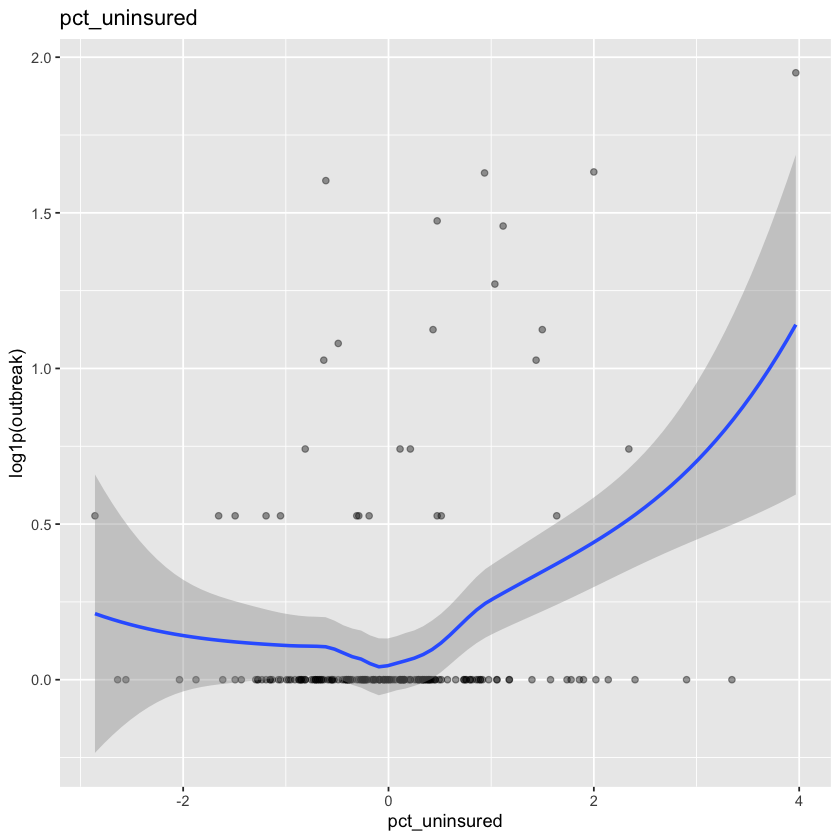

`geom_smooth()` using formula = 'y ~ x'


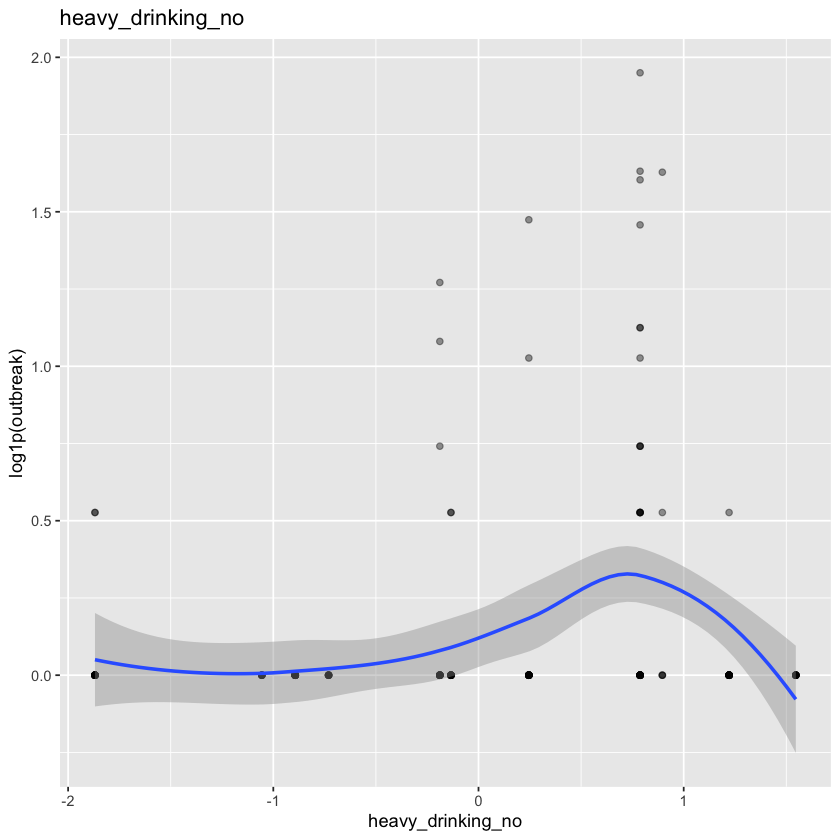

`geom_smooth()` using formula = 'y ~ x'


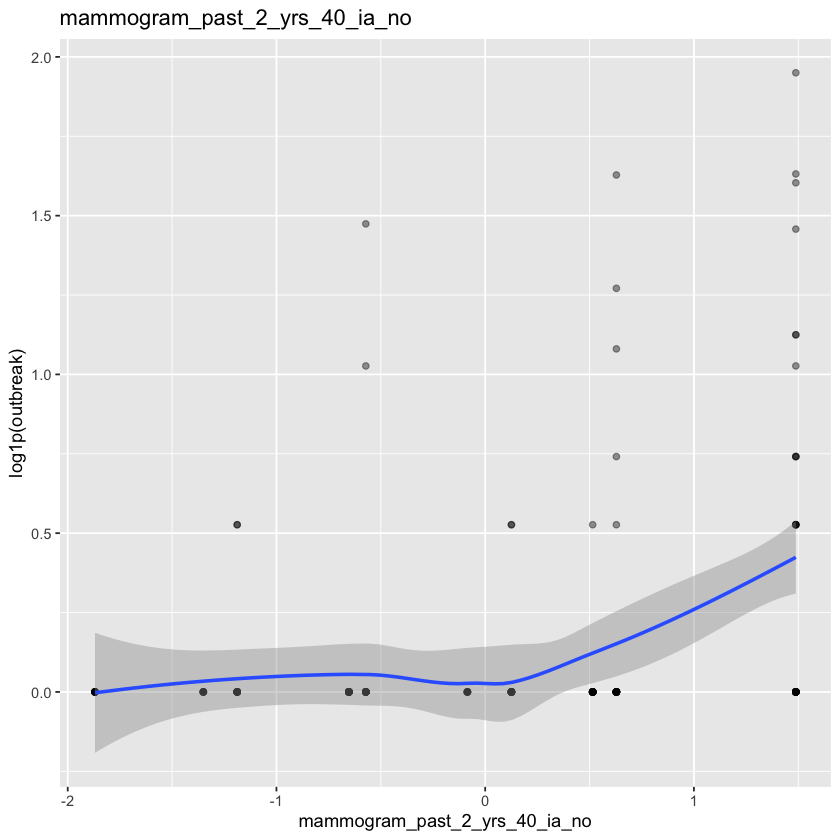

`geom_smooth()` using formula = 'y ~ x'


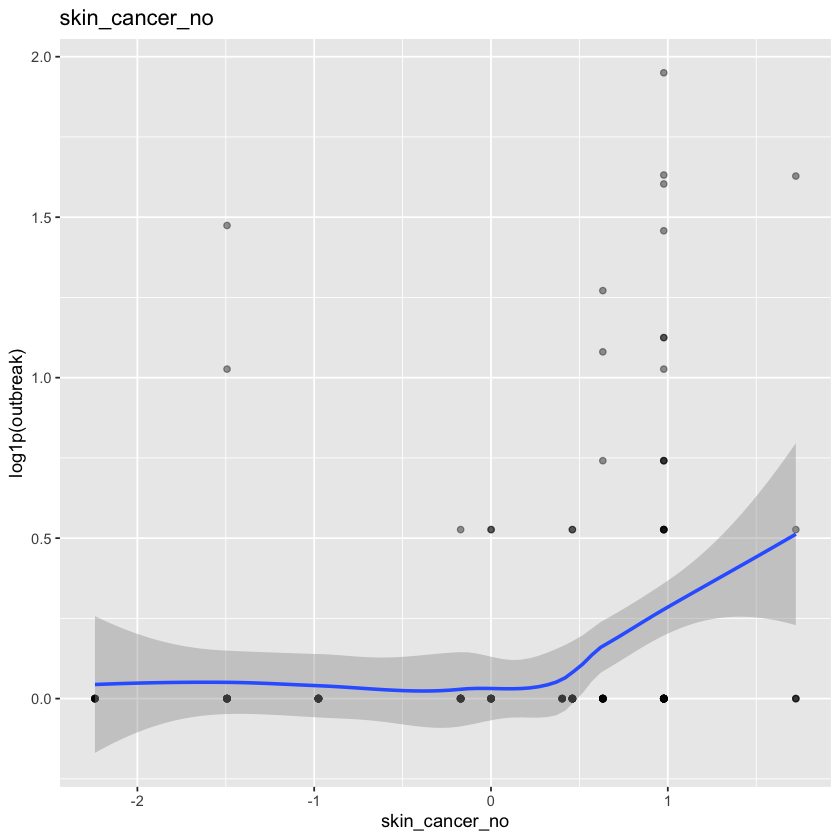

`geom_smooth()` using formula = 'y ~ x'


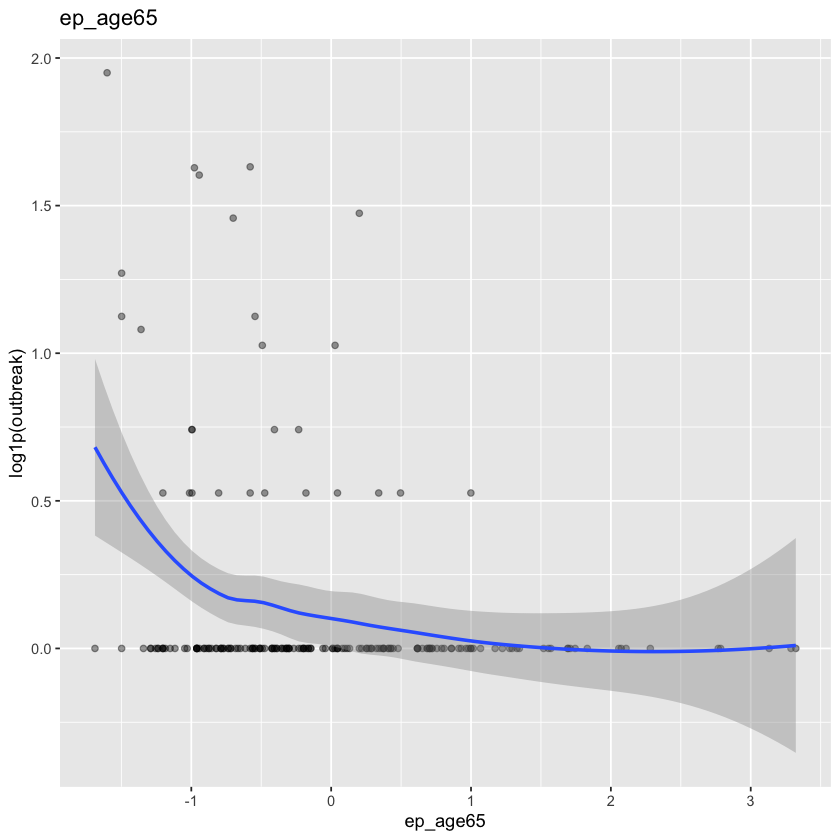

`geom_smooth()` using formula = 'y ~ x'


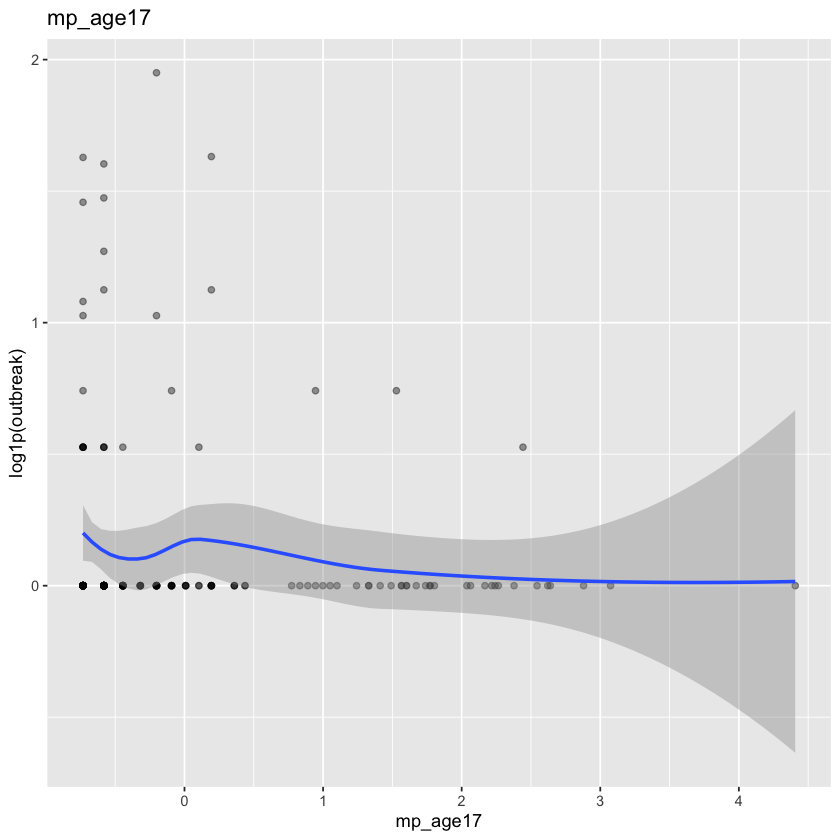

`geom_smooth()` using formula = 'y ~ x'


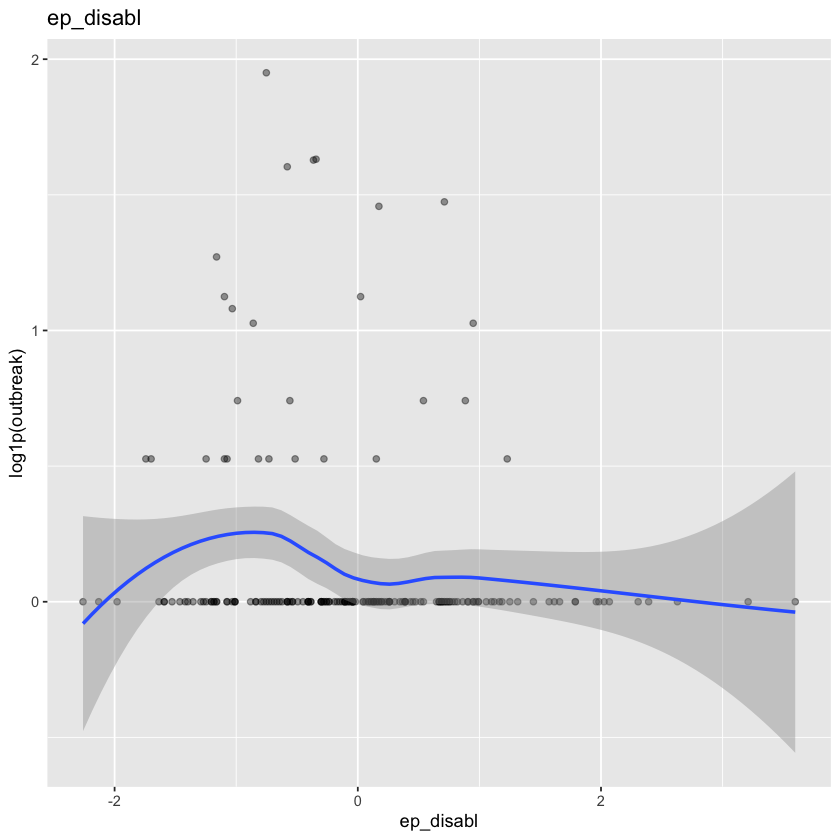

`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
"pseudoinverse used at -0.64061"
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
"neighborhood radius 1.5784"
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
"reciprocal condition number  0"
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
"There are other near singularities as well. 2.4282"
Warning message in predLoess(object$y, object$x, newx = if (is.null(newdata)) object$x else if (is.data.frame(newdata)) as.matrix(model.frame(delete.response(terms(object)), :
"pseudoinverse used at -0.64061"
Warning message in predLoess(object$y, object$x, newx = if (is.null(newdata)) object$x else if (is.data.frame(newdata)) as.matrix(model.frame(delete.response(terms(object)), :
"neighborhood radius 1.5784"
Warning message in predLoess(object$y,

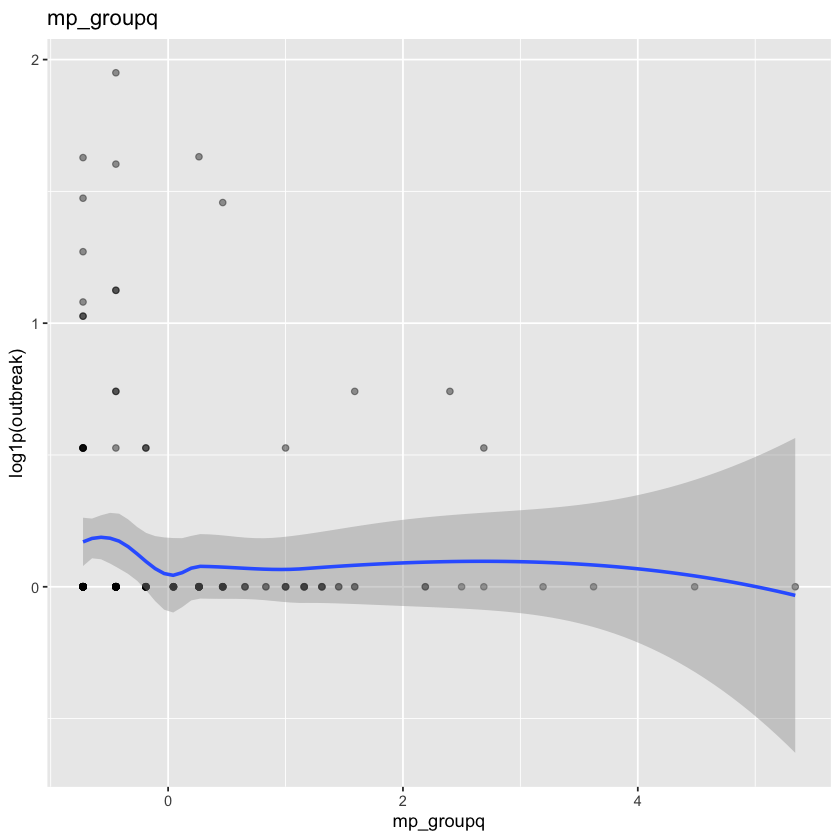

`geom_smooth()` using formula = 'y ~ x'


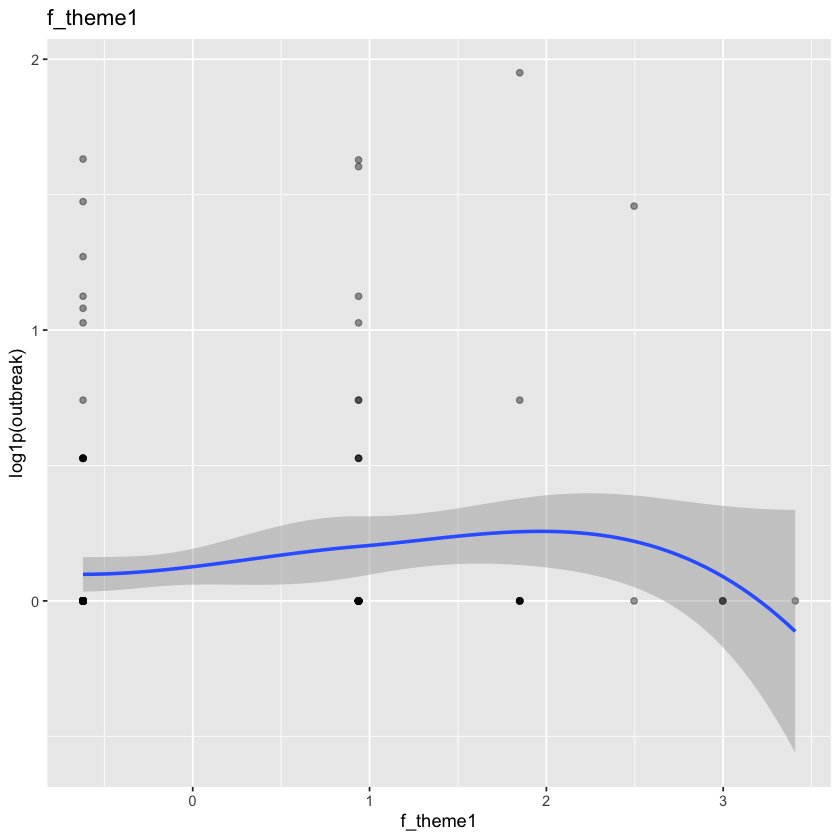

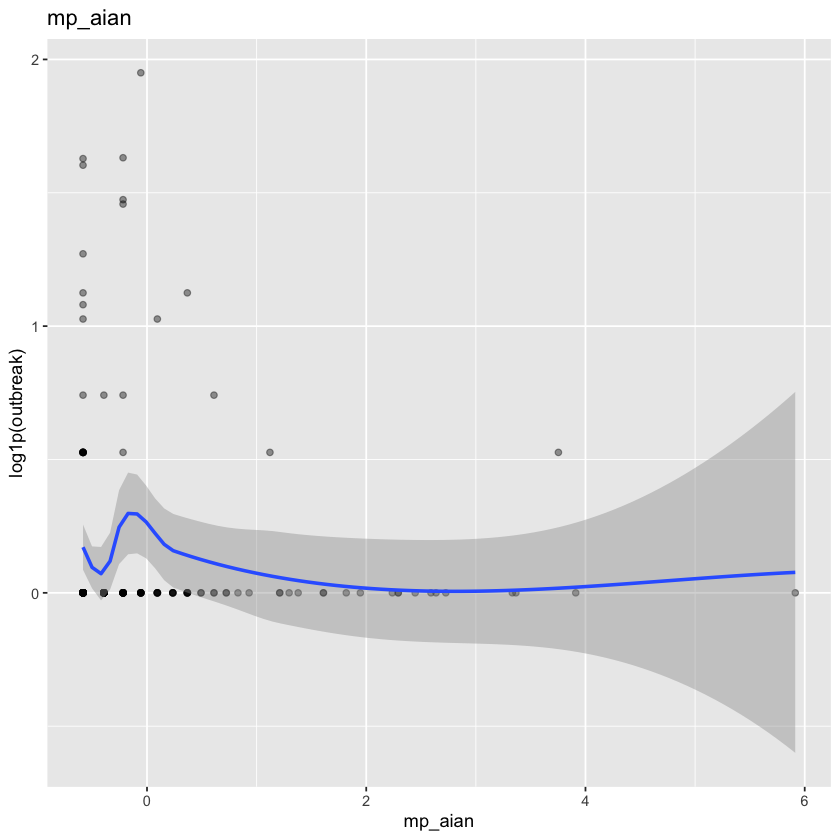

In [67]:
library(glmmTMB)
# Log-transform skewed variables before scaling
skewed_vars <- c("mp_age17", "mp_aian", "mp_groupq", "f_theme1")

model_df_scaled <- model_df
model_df_scaled[, skewed_vars] <- log1p(model_df[, skewed_vars])
model_df_scaled[, lasso_vars]  <- scale(model_df_scaled[, lasso_vars])

# Save center/scale attributes for test set
scale_center <- attr(scale(model_df_scaled[, lasso_vars]), "scaled:center")
scale_sd     <- attr(scale(model_df_scaled[, lasso_vars]), "scaled:scale")

test_df_scaled <- test_df
test_df_scaled[, skewed_vars] <- log1p(test_df[, skewed_vars])
test_df_scaled[, lasso_vars]  <- scale(test_df_scaled[, lasso_vars],
                                        center = scale_center,
                                        scale  = scale_sd)


fit_zinb <- glmmTMB(
  outbreak ~ pct_uninsured + heavy_drinking_no + mammogram_past_2_yrs_40_ia_no +
    skin_cancer_no + poly(ep_age65, 2) + poly(mp_age17, 2)  + ep_disabl + mp_groupq +
    f_theme1 + mp_aian +
    offset(log(enrollment)) + (1 | PHR),
  ziformula = ~1,
  data   = model_df_scaled,
  family = nbinom2()
)
summary(fit_zinb)

# Predictions on test set
test_df <- cbind(
  data.frame(outbreak = test$outbreak, enrollment = test$enrollment, PHR = test$phr),
  test[, lasso_vars, drop = FALSE]
)

pred_zinb <- predict(fit_zinb, newdata = test_df, type = "response")

summary(pred_zinb)
table(round(pred_zinb))
table(actual = test_df$outbreak, predicted = round(pred_zinb))
# Are predictors on wildly different scales?
summary(model_df[, lasso_vars])

# How many true zeros?
mean(model_df$outbreak == 0)

range(model_df$heavy_drinking_no)
range(model_df_scaled$heavy_drinking_no)

# Check if plain NB has finite SEs
summary(fit)

library(car)

vif_fit <- glm(
  outbreak ~ pct_uninsured + heavy_drinking_no + mammogram_past_2_yrs_40_ia_no +
    skin_cancer_no + ep_age65 + mp_age17 + ep_disabl + mp_groupq +
    f_theme1 + mp_aian + offset(log(enrollment)),
  data   = model_df_scaled,
  family = MASS::negative.binomial(theta = 1)
)
vif(vif_fit)
library(ggplot2)

# Check each predictor against log(outbreak+1)
for (v in lasso_vars) {
  p <- ggplot(model_df_scaled, aes_string(x = v, y = "log1p(outbreak)")) +
    geom_point(alpha = 0.4) +
    geom_smooth(method = "loess", se = TRUE) +
    ggtitle(v)
  print(p)
}


In [56]:
rmse <- sqrt(mean((test_df$outbreak - pred_zinb)^2))
mae  <- mean(abs(test_df$outbreak - pred_zinb))
r2   <- cor(test_df$outbreak, pred_zinb)^2

cat(sprintf("RMSE: %.4f\nMAE:  %.4f\nR²:   %.4f\n", rmse, mae, r2))
data.frame(
  actual    = test_df$outbreak,
  predicted = round(pred_zinb),
  correct   = ifelse(test_df$outbreak == 0, round(pred_zinb) == 0, round(pred_zinb) > 0)
) |> arrange(desc(actual)) |> filter(!(actual == 0 & correct == TRUE))

RMSE: 31977064246406303472644404049918971415844939104256.0000
MAE:  6305138734690949757327030107830751516527339503616.0000
R<U+00B2>:   0.7829


actual,predicted,correct
<dbl>,<dbl>,<lgl>
14,2.402920e+50,TRUE
5,4.670976e+49,TRUE
4,1.482431e+35,TRUE
3,2.545830e+45,TRUE
3,4.190202e+43,TRUE
2,1.488837e+44,TRUE
1,4.532351e+35,TRUE
1,4.628980e+43,TRUE
1,2.382677e+49,TRUE


After 12 iterations, +1.2 secs: 

 rejected 13 attributes: Cervical Cancer Screening Pa - No, Difficulty Concentrating - Yes, General Health - Good, Heavy Drinking - Females - Yes, Interfere w Social Act - Usually and 8 more;

 still have 14 attributes left.


After 16 iterations, +1.5 secs: 

 rejected 8 attributes: BMI 5 Categories - Underweight, ClnscpySgmscpy - Both, Current E-cig User - Yes, Kidney Disease - Yes, Quit Smoking in Past Yr - No and 3 more;

 still have 6 attributes left.


After 19 iterations, +1.7 secs: 

 rejected 3 attributes: Hlth Affected Activ 5+ Days - None to less than 5 days, Pap Test Past 3 Yrs 21-65 IA - No, Sigm Past 10 Yrs 50-75 IA - No;

 still have 3 attributes left.


After 38 iterations, +2.8 secs: 

 rejected 1 attribute: Poor Mental Health 5+ Days - 5 or more days;

 still have 2 attributes left.




Boruta confirmed 1 variables:
[1] "pct_uninsured"


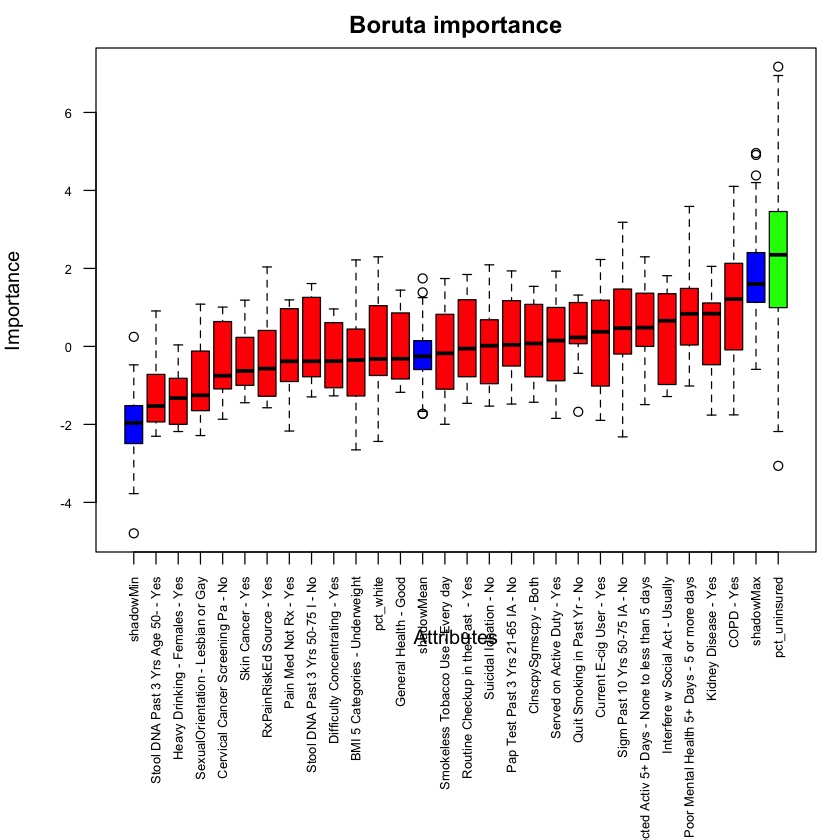

In [6]:
library(Boruta)

set.seed(42)
boruta_out <- Boruta(x = X_clean, y = y, maxRuns = 150, doTrace = 1)

boruta_fixed <- TentativeRoughFix(boruta_out)
boruta_vars  <- getSelectedAttributes(boruta_fixed, withTentative = FALSE)

cat("Boruta confirmed", length(boruta_vars), "variables:\n")
print(boruta_vars)

# Plot
par(mar = c(12, 4, 2, 1))
plot(boruta_fixed, las = 2, cex.axis = 0.65, main = "Boruta importance")

Rows: 254 Columns: 555
-- Column specification --------------------------------------------------------
Delimiter: ","
chr   (1): County
dbl (531): cve, outbreak, enrollment, PHR, pct_hispanic, pct_black, pct_whit...
lgl  (23): median_income, Advised to Cut Down Salt - Do not use salt, Diabet...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


Covariate matrix: 254 rows x 550 columns


Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung is

After Spearman screen: 276 candidates
# A tibble: 276 x 3
   variable                                                   rho     p_value
   <chr>                                                    <dbl>       <dbl>
 1 Mammogram Past 2 Yrs 40+ IA - No                         0.311 0.000000415
 2 Mammogram Past 2 Yrs 40+ IA - Yes                       -0.311 0.000000415
 3 Mammogram Past 2 Yrs 50+ IA - Yes                       -0.309 0.000000527
 4 Mammogram Past 2 Yrs 50+ IA - No                         0.309 0.000000527
 5 Poor Mental Health 14+ Days - None to less than 14 days  0.306 0.000000664
 6 Poor Mental Health 14+ Days - 14 or more days           -0.306 0.000000664
 7 Sigm Past 5 Yrs Age 50-75 - No                           0.301 0.00000101 
 8 Sigm Past 5 Yrs 50-75 IA - No                            0.301 0.00000101 
 9 Depressive Disorder - No                                 0.292 0.00000222 
10 Depressive Disorder - Yes                               -0.292 0.00000222 
# i 26

 Family: nbinom2  ( log )
Formula:          
outbreak ~ cve + `Kidney Disease - Yes` + `ClnscpySgmscpy - Both` +  
    `Suicidal Ideation - Yes` + F_LIMENG + E_LIMENG + `Quit Smoking in Past Yr - No` +  
    `Cervical Cancer Screening Pa - No` + pct_uninsured + offset(log(enrollment)) +  
    (1 | PHR)
Data: model_df

      AIC       BIC    logLik -2*log(L)  df.resid 
    379.9     422.1    -178.0     355.9       237 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 PHR    (Intercept) 1.624    1.274   
Number of obs: 249, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.162 

Conditional model:
                                      Estimate Std. Error z value Pr(>|z|)   
(Intercept)                          7.832e+00  1.310e+01   0.598  0.54998   
cve                                  3.217e-01  1.761e-01   1.827  0.06772 . 
`Kidney Disease - Yes`              -5.643e-02  1.025e+00  -0.055  0.95610   
`ClnscpySgmscpy - Both`             -4.576e-

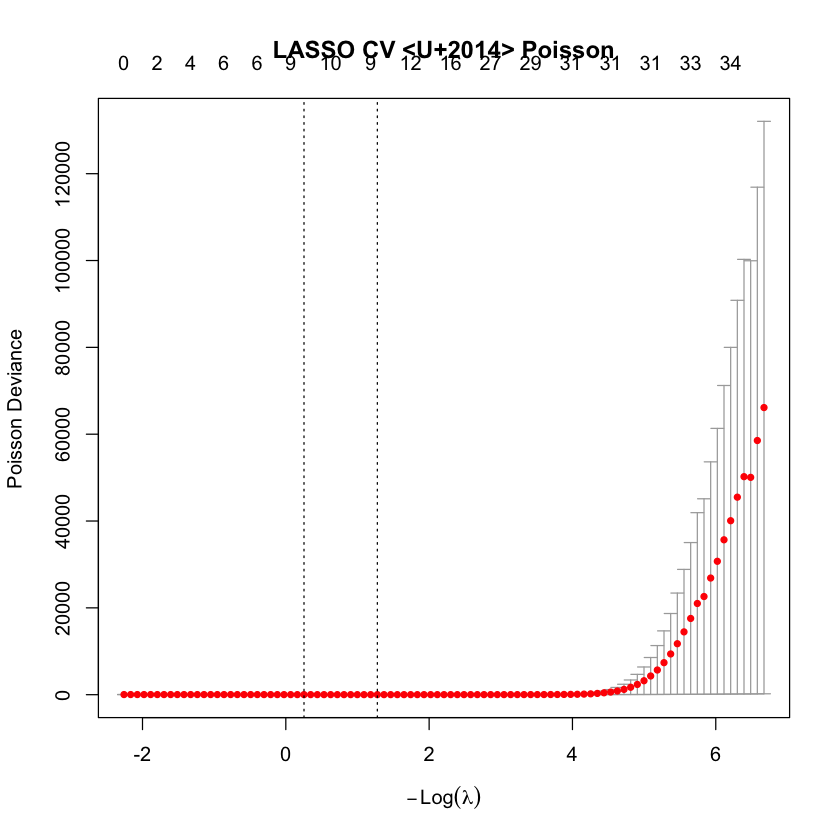

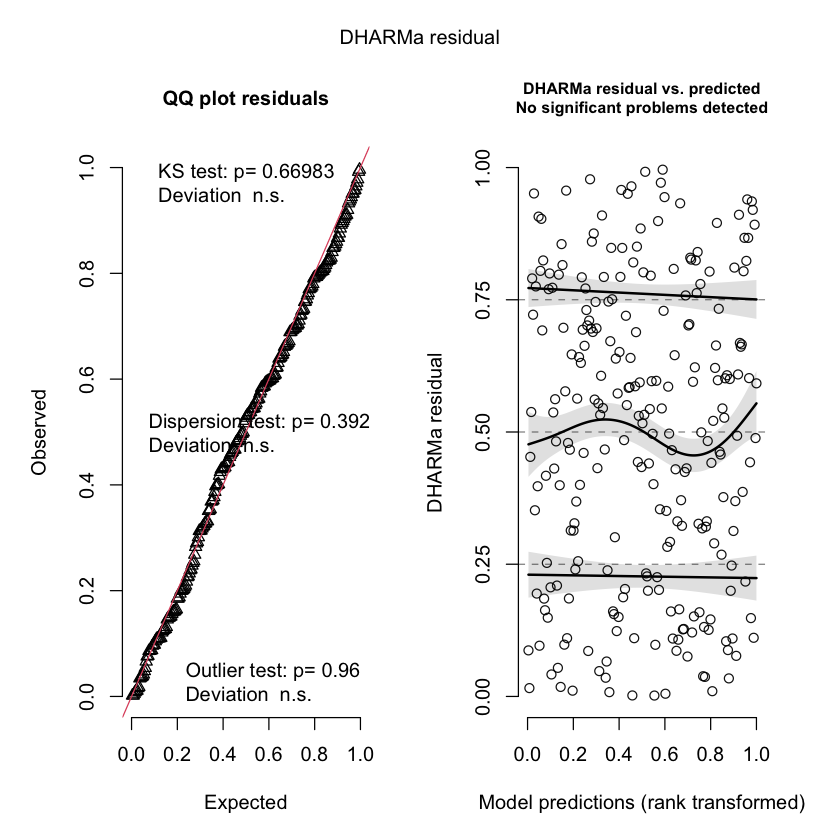

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# outbreak ~ automated variable selection pipeline
# Data     : merged_with_svi.csv  (254 counties, 555 columns)
# Outcome  : outbreak (count)
# Offset   : log(enrollment)
# Random FX: (1 | PHR)
# Family   : nbinom2
# ══════════════════════════════════════════════════════════════════════════════

library(tidyverse)
library(glmnet)
library(glmmTMB)
library(caret)
library(DHARMa)


# ── 0. Load data ──────────────────────────────────────────────────────────────

df <- read_csv("data/merged_with_svi.csv")


# ── 1. Define outcome, offset, grouping, and covariate matrix ─────────────────

outcome    <- df$outbreak
offset_var <- log(df$enrollment)
PHR        <- df$PHR

# All columns except identifiers and outcomes
X_all <- df %>%
  select(-County, -cve, -outbreak, -enrollment, -PHR) %>%
  mutate(across(everything(), ~ suppressWarnings(as.numeric(as.character(.))))) %>%
  mutate(across(everything(), ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))

cat("Covariate matrix:", nrow(X_all), "rows x", ncol(X_all), "columns\n")


# ── 2. Spearman screen  (keep p < 0.2) ───────────────────────────────────────

spearman_screen <- function(X, y, p_threshold = 0.2) {
  map_dfr(names(X), function(var) {
    x  <- X[[var]]
    ok <- !is.na(x) & !is.na(y)
    if (sum(ok) < 10) return(NULL)
    test <- cor.test(x[ok], y[ok], method = "spearman", exact = FALSE)
    tibble(variable = var, rho = test$estimate, p_value = test$p.value)
  }) %>%
    filter(p_value < p_threshold) %>%
    arrange(p_value)
}

candidates <- spearman_screen(X_all, outcome)
cat("After Spearman screen:", nrow(candidates), "candidates\n")
print(candidates)


# ── 3. Collinearity filter  (drop variables with |r| > 0.70) ─────────────────

X_cand    <- X_all[, candidates$variable, drop = FALSE]
cor_mat   <- cor(X_cand, use = "pairwise.complete.obs")
to_remove <- findCorrelation(cor_mat, cutoff = 0.70, names = TRUE)
X_filt    <- X_cand[, !names(X_cand) %in% to_remove, drop = FALSE]
cat("After collinearity filter:", ncol(X_filt), "variables\n")


# ── 4. Drop rows with NA outcome or non-finite offset ────────────────────────

valid   <- !is.na(outcome) & is.finite(offset_var)
y       <- outcome[valid]
offs    <- offset_var[valid]
phr     <- factor(PHR[valid])
X_clean <- X_filt[valid, , drop = FALSE]

cat("Rows after cleaning:", sum(valid), "\n")


# ── 5. LASSO  (Poisson, lambda.1se) ──────────────────────────────────────────

X_mat <- model.matrix(~ . - 1, data = X_clean)

set.seed(42)
cv_lasso <- cv.glmnet(
  x      = X_mat,
  y      = y,
  offset = offs,
  family = "poisson",
  alpha  = 1
)
plot(cv_lasso, main = "LASSO CV — Poisson")

lasso_coef <- coef(cv_lasso, s = "lambda.1se")
lasso_vars <- rownames(lasso_coef)[
  lasso_coef[, 1] != 0 & !grepl("Intercept", rownames(lasso_coef))
]
lasso_vars <- gsub("^`|`$", "", lasso_vars)
lasso_vars <- lasso_vars[lasso_vars %in% names(X_clean)]

cat("\nLASSO selected", length(lasso_vars), "variables:\n")
print(lasso_vars)

cat("cve selected by LASSO:", "cve" %in% lasso_vars, "\n")


# ── 6. Final model  outbreak ~ cve + lasso_vars + offset + (1|PHR) ───────────

keep_vars <- union("cve", lasso_vars)

model_df <- bind_cols(
  outbreak   = y,
  enrollment = exp(offs),
  PHR        = phr,
  df[valid, "cve", drop = FALSE],
  X_clean[, setdiff(keep_vars, "cve"), drop = FALSE]
)

formula_final <- reformulate(
  termlabels = c(
    paste0("`", keep_vars, "`"),
    "offset(log(enrollment))",
    "(1 | PHR)"
  ),
  response = "outbreak"
)

fit_final <- glmmTMB(formula_final, data = model_df, family = nbinom2())
summary(fit_final)


# ── 7. DHARMa diagnostics ────────────────────────────────────────────────────

sim <- simulateResiduals(fit_final)
plot(sim)

After 13 iterations, +1.6 secs: 

 rejected 39 attributes: A One C - Yes, BMI 5 Categories - Underweight, COPD - Yes, Cervical Cancer Screening Pa - No, ClnscpySgmscpy - Both and 34 more;

 still have 9 attributes left.


After 17 iterations, +2 secs: 

 rejected 1 attribute: F_NOHSDP;

 still have 8 attributes left.


After 20 iterations, +2.2 secs: 

 rejected 1 attribute: E_NHPI;

 still have 7 attributes left.


After 44 iterations, +3.9 secs: 

 rejected 1 attribute: E_LIMENG;

 still have 6 attributes left.


After 47 iterations, +4.1 secs: 

 rejected 1 attribute: pct_uninsured;

 still have 5 attributes left.


After 52 iterations, +4.4 secs: 

 confirmed 1 attribute: Suicidal Ideation - No;

 still have 4 attributes left.


After 60 iterations, +4.9 secs: 

 confirmed 1 attribute: RPL_THEME1;

 still have 3 attributes left.


After 66 iterations, +5.3 secs: 

 confirmed 1 attribute: EPL_MOBILE;

 still have 2 attributes left.


After 71 iterations, +5.6 secs: 

 confirmed 1 at

Boruta confirmed 5 variables:
[1] "Suicidal Ideation - No"                     
[2] "EPL_MOBILE"                                 
[3] "F_THEME1"                                   
[4] "Poor Mental Health 5+ Days - 5 or more days"
[5] "RPL_THEME1"                                 


 Family: nbinom2  ( log )
Formula:          
outbreak ~ cve + `Suicidal Ideation - No` + EPL_MOBILE + F_THEME1 +  
    `Poor Mental Health 5+ Days - 5 or more days` + RPL_THEME1 +  
    offset(log(enrollment)) + (1 | PHR)
Data: model_boruta

      AIC       BIC    logLik -2*log(L)  df.resid 
    382.4     414.1    -182.2     364.4       240 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 PHR    (Intercept) 6.08     2.466   
Number of obs: 249, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.167 

Conditional model:
                                              Estimate Std. Error z value
(Intercept)                                   65.56229   89.24860   0.735
cve                                            0.41511    0.14088   2.946
`Suicidal Ideation - No`                      -0.68609    0.92707  -0.740
EPL_MOBILE                                    -0.28387    1.10708  -0.256
F_THEME1                                      -0.06615    0.3621

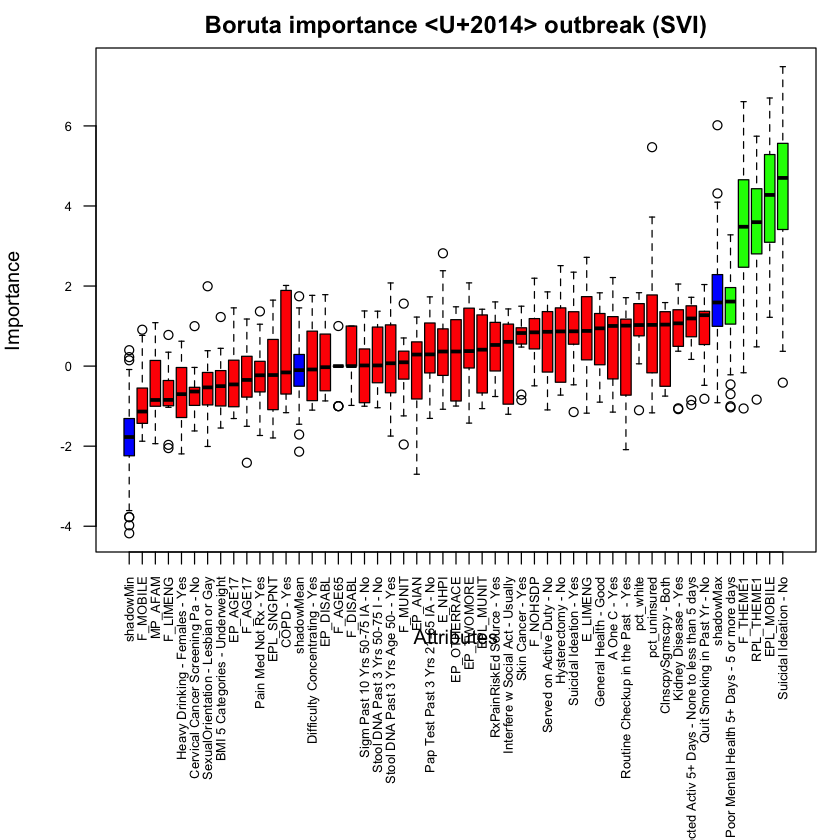


In Boruta, not LASSO: Suicidal Ideation - No EPL_MOBILE F_THEME1 Poor Mental Health 5+ Days - 5 or more days RPL_THEME1 
In LASSO, not Boruta: Kidney Disease - Yes ClnscpySgmscpy - Both Suicidal Ideation - Yes F_LIMENG E_LIMENG Quit Smoking in Past Yr - No Cervical Cancer Screening Pa - No pct_uninsured 
In both:               


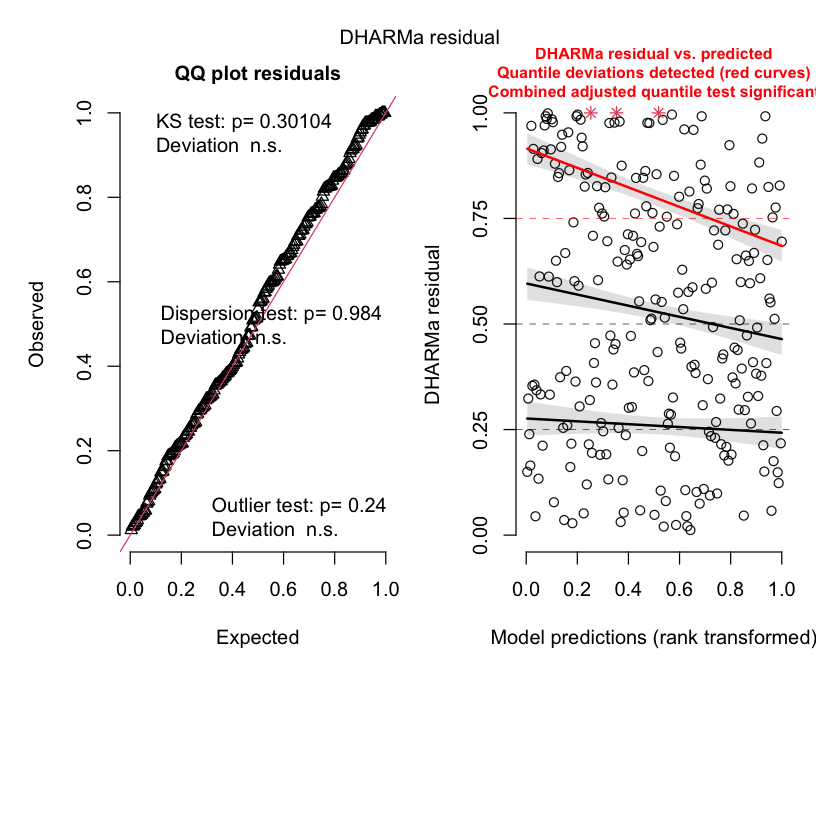

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Boruta variable selection
# Run after outbreak_selection_svi.R (needs X_clean, y, offs, phr, valid)
# ══════════════════════════════════════════════════════════════════════════════

library(Boruta)
library(glmmTMB)
library(DHARMa)


# ── 1. Run Boruta ─────────────────────────────────────────────────────────────

set.seed(42)
boruta_out <- Boruta(x = X_clean, y = y, maxRuns = 150, doTrace = 1)

boruta_fixed <- TentativeRoughFix(boruta_out)
boruta_vars  <- getSelectedAttributes(boruta_fixed, withTentative = FALSE)

cat("Boruta confirmed", length(boruta_vars), "variables:\n")
print(boruta_vars)

par(mar = c(12, 4, 2, 1))
plot(boruta_fixed, las = 2, cex.axis = 0.65, main = "Boruta importance — outbreak (SVI)")


# ── 2. Final model using Boruta-selected variables ───────────────────────────

keep_boruta <- union("cve", boruta_vars)

model_boruta <- bind_cols(
  outbreak   = y,
  enrollment = exp(offs),
  PHR        = phr,
  df[valid, "cve", drop = FALSE],
  X_clean[, setdiff(keep_boruta, "cve"), drop = FALSE]
)

formula_boruta <- reformulate(
  termlabels = c(
    paste0("`", keep_boruta, "`"),
    "offset(log(enrollment))",
    "(1 | PHR)"
  ),
  response = "outbreak"
)

fit_boruta <- glmmTMB(formula_boruta, data = model_boruta, family = nbinom2())
summary(fit_boruta)


# ── 3. DHARMa diagnostics ────────────────────────────────────────────────────

sim_boruta <- simulateResiduals(fit_boruta)
plot(sim_boruta)


# ── 4. Overlap with LASSO ────────────────────────────────────────────────────

cat("\nIn Boruta, not LASSO:", setdiff(boruta_vars, lasso_vars), "\n")
cat("In LASSO, not Boruta:", setdiff(lasso_vars,  boruta_vars), "\n")
cat("In both:             ", intersect(lasso_vars, boruta_vars), "\n")